In [1]:
from helpers.plotting_functions import plot_3d_gp, plot_3d_data, plot_single_input_gp_posterior
from helpers.util_functions import prior_distribution, reparameterize_model_full, reparameterize_model_trainable
from laplace_model_selection.metrics import Lap0, LapAIC, LapBIC, AIC, BIC, NestedSampling, MLL, MAP
from helpers.training_functions import granso_optimization
from helpers.gp_classes import ExactGPModel
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import torch
import gpytorch
torch.set_default_dtype(torch.float64)

rng_state = torch.tensor(pd.read_csv('rng_state.csv', header=None).values, dtype=torch.uint8).squeeze()
torch.set_rng_state(rng_state)
rng_state = torch.get_rng_state()
rng_state

tensor([ 28, 164, 181,  ...,   0,   0,   0], dtype=torch.uint8)

In [2]:
eval = False

In [ ]:
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import dill

# Find all points inside the confidence ellipse
def percentage_inside_ellipse(mu, K, points, sigma_level=2):
    L = np.linalg.cholesky(K)
    threshold = sigma_level ** 2
    count = 0
    for point in points:
        res = np.array(point - mu) @ np.linalg.inv(L)
        if res @ res <= threshold:
            count += 1
    return count / len(points)

# Stolen from https://matplotlib.org/stable/gallery/statistics/confidence_ellipse.html
def confidence_ellipse(mu, K, ax, n_std=2.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.

    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.

    ax : matplotlib.axes.Axes
        The Axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`

    Returns
    -------
    matplotlib.patches.Ellipse
    """

    cov = K
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    # Calculating the standard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = mu[0] 

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = mu[1]

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

def nested_sampling_plot(model, model_evidence_log, xdim=0, ydim=1, filter_type="none", std_filter=None, show_last_num=None, return_figure=False, title_add="", fig=None, ax=None, display_figure=True, plot_mll_opt=False, mll_opt_params=None, plot_lap=False, Lap0_logs=None, LapAIC_logs=None, LapBIC_logs=None, lap_colors = ["r", "pink", "black"], Lap_hess=None):

    if not (fig and ax):
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    with open(f"{model_evidence_log['res file']}", "rb") as f:
        res = dill.load(f)
    
    # Plot the actual figure
    param_names = [l[0] for l in list(model.named_parameters())]

    # Find the best value and the corresponding hyperparameters
    best_idx = np.argmax(res.logl)
    best_hyperparameters = res.samples[best_idx]

    # Do an outlier cleanup based on the std_filter or the last "show_last_num" samples
    if show_last_num is not None:
        if type(show_last_num) is int:
            # Find value of "show_last_num" sample
            filter_val = sorted(res.logl, reverse=True)[show_last_num]
            mask = res.logl > filter_val
        elif type(show_last_num) is float:
            # Raise an error if show_last_num is not between 0 and 1
            if show_last_num < 0 or show_last_num > 1:
                raise ValueError("show_last_num must be between 0 and 1")
            # assume that it is a percentage of the total samples
            filter_val = sorted(res.logl, reverse=True)[int(len(res.logl)*show_last_num)]
            mask = res.logl > filter_val
    # Do an outlier cleanup on res.logz
    elif std_filter is None and not filter_type == "none" and not show_last_num is None:
        raise ValueError("Cannot use both filter_type and show_last_num at the same time")
    
    elif show_last_num is None and not std_filter is None:
        logz_std = np.std(res.logl)
        if filter_type == "max":
            mask = res.logl >= max(res.logl)+std_filter*logz_std
        elif filter_type == "mean":
            raise NotImplementedError("This filter type is not implemented yet")
            logz_mean = np.mean(res.logz)
            mask = np.all(logz_mean - abs(std_filter) * logz_std <= res.logz <= logz_mean + abs(std_filter) * logz_std)
    elif filter_type == "none":
        mask = res.logl == res.logl



    likelihood_surface_scatter = ax.scatter(res.samples[:,xdim][mask], res.samples[:,ydim][mask], c=res.logl[mask], s=3)
    # Best found hyperparameters
    ax.scatter(best_hyperparameters[xdim], best_hyperparameters[ydim], c="r", s=10)

    if plot_mll_opt and not mll_opt_params is None:
        ax.scatter(mll_opt_params[xdim], mll_opt_params[ydim], c="black", s=10)
        # Add a small text beside the point saying "MLL"
        ax.text(mll_opt_params[xdim], mll_opt_params[ydim], "MLL", fontsize=12, color="black", verticalalignment='center', horizontalalignment='right')
    
    coverages = list()
    if plot_lap:
        # Plot the Laplace levels
        for lap_log, lap_color in zip([Lap0_logs, LapAIC_logs, LapBIC_logs], lap_colors):
            if lap_log is None:
                continue
            lap_param_mu = torch.tensor(lap_log["parameter values"])
            # Wait a minute, isn't the Hessian the inverse of the covariance matrix? Yes, see Murphy PML 1 eq. (7.228)
            lap_param_cov_matr = torch.linalg.inv(lap_log["Hessian post correction"])
            # Calculate the amount of samples that are covered by the 1 sigma and 2 sigma interval based on the lap_mu and lap_cov values
            lap_2_sig_coverage = percentage_inside_ellipse(np.array(lap_param_mu).flatten(), lap_param_cov_matr.detach().numpy(), res.samples[mask])
            coverages.append(lap_2_sig_coverage)
            #ax.scatter(lap_param_mu[xdim], lap_param_mu[ydim], c="b", s=10)

            # Plot the std points
            lap_mu_filtered = lap_param_mu.numpy()[[xdim, ydim]] 
            lap_cov_filtered = lap_param_cov_matr.numpy()[[xdim, ydim]][:,[xdim, ydim]]
            #lap_var_ellipse_x, lap_var_ellipse_y = get_std_points(lap_mu_filtered.flatten(), lap_cov_filtered)
            #plt.scatter(lap_var_ellipse_x, lap_var_ellipse_y, c="b", s=1)
            confidence_ellipse(lap_mu_filtered, lap_cov_filtered, ax, n_std=2, edgecolor=lap_color, lw=1)
        if not Lap_hess is None:
            # It can happen that the Hessian is not invertible, in that case drawing the confidence ellipse is not possible
            try:
                lap_param_cov_matr = torch.linalg.inv(Lap_hess)
                lap_2_sig_coverage = percentage_inside_ellipse(lap_param_mu.flatten().numpy(), lap_param_cov_matr.numpy(), res.samples[mask])

                coverages.append(lap_2_sig_coverage)

                lap_mu_filtered = lap_param_mu.numpy()[[xdim, ydim]] 
                lap_cov_filtered = lap_param_cov_matr.numpy()[[xdim, ydim]][:,[xdim, ydim]]
                confidence_ellipse(lap_mu_filtered, lap_cov_filtered, ax, n_std=2, edgecolor="black", lw=1)
            except Exception as e:
                print(e)

    ax.set_title(f"#Samples: {sum(res.ncall)}")
    if show_last_num is not None:
        ax.set_title(ax.get_title() + f"; {coverages[0]*100:.0f}% inside 2 sigma\n{show_last_num} best accepted samples")
    elif not std_filter is None:
        ax.set_title(ax.get_title() + f"; {coverages[0]*100:.0f}% inside 2 sigma\n{filter_type}: {std_filter:.0e}")
    elif len(coverages) > 0:
        ax.set_title(ax.get_title() + f"; {coverages[0]*100:.0f}% inside 2 sigma\n")
    ax.set_xlabel(param_names[xdim])
    ax.set_ylabel(param_names[ydim])

    plt.colorbar(likelihood_surface_scatter)

    if return_figure:
        return fig, ax
    if display_figure:
        plt.show()
    return None, None


def outlier_cleanup(values, mode="none", filter=None):
    """
    Outlier cleanup function for the nested sampling results.

    Parameters
    ----------
    values : array-like
        The values to be filtered.
    mode : str
        The mode of filtering. Can be "none", "max", "min", "mean", or "value".
    filter : float or int
        The filter value. If mode is "max" or "min", it can be a percentage (float) or a number of samples (int). 
        If mode is "mean", it is the number of standard deviations from the mean. If mode is "value", it is the threshold value.

    """

    # Filter modes: "none", "max", "mean", "value"
    # "none": There is no filtering, just pass everything
    # "max": Only display the highest "std_filter" samples. If "std_filter" is float, use percent, if int, use the number of samples
    # "min": Only display the smallest "std_filter" samples. If "std_filter" is float, use percent, if int, use the number of samples
    # "mean": Only display the samples that are within "std_filter" standard deviations of the mean
    # "value": Only display the samples that are greater than "std_filter"

    masked=None

    if mode == "none":
        masked = values == values
    elif mode == "min":
        if type(filter) is float:
            # Raise an error if show_last_num is not between 0 and 1
            if filter < 0 or filter > 1:
                raise ValueError("filter must be between 0 and 1")
            # assume that it is a percentage of the total samples
            filter_val = sorted(values)[int(len(values)*filter)]
            masked = values < filter_val
        elif type(filter) is int:
            # Find value of "show_last_num" sample
            filter_val = sorted(values)[filter]
            masked = values < filter_val 
    elif mode == "max":
        if type(filter) is float:
            # Raise an error if show_last_num is not between 0 and 1
            if filter < 0 or filter > 1:
                raise ValueError("filter must be between 0 and 1")
            # assume that it is a percentage of the total samples
            filter_val = sorted(values, reverse=True)[int(len(values)*filter)]
            masked = values > filter_val
        elif type(filter) is int:
            # Find value of "show_last_num" sample
            filter_val = sorted(values, reverse=True)[filter]
            masked = values > filter_val 
    elif mode == "mean":
        raise NotImplementedError("This filter type is not implemented yet")
        logz_mean = np.mean(res.logz)
        masked = np.all(logz_mean - abs(filter) * logz_std <= res.logz <= logz_mean + abs(std_filter) * logz_std)
    elif mode == "value":
        masked = values > filter
    return masked



# More general version of the nested sampling plotting function
def scatter_function_visualization(positions, values, fig=None, ax=None, axis_names=None, show_best=False, xdim=0, ydim=1, filter_mode="none", std_filter=None, show_last_num=None, return_figure=False, title_add="", display_figure=True):
   
    if not (fig and ax):
        fig, ax = plt.subplots(1, 1, figsize=(8, 6)) 

    mask = outlier_cleanup(values, filter_mode, std_filter)
    
    filtered_x_dim = positions[:,xdim][mask]
    filtered_y_dim = positions[:,ydim][mask]
    filtered_colors = values[mask]
    likelihood_surface_scatter = ax.scatter(filtered_x_dim, filtered_y_dim, c=filtered_colors, s=3)

    if show_best:
        # Find the best value and the corresponding hyperparameters
        best_idx = np.argmax(values)
        best_hyperparameters = positions[best_idx]
        # Best found hyperparameters
        ax.scatter(best_hyperparameters[xdim], best_hyperparameters[ydim], c="r", s=10)

    if show_last_num is not None:
        ax.set_title(f"#Samples: {len(values)}; {show_last_num} best accepted samples")
    elif not std_filter is None:
        ax.set_title(f"#Samples: {len(values)}; {filter_mode}: {std_filter:.0e}")
    else:
        ax.set_title(f"#Samples: {len(values)}; ")
    ax.set_xlabel(axis_names[0])
    ax.set_ylabel(axis_names[1])

    plt.colorbar(likelihood_surface_scatter)

    if return_figure:
        return fig, ax
    if display_figure:
        plt.show()
    return None, None


In [4]:
from sklearn.datasets import fetch_openml
import polars as pl

co2 = fetch_openml(data_id=41187, as_frame=True)

co2_data = pl.DataFrame(co2.frame[["year", "month", "day", "co2"]]).select(
    pl.date("year", "month", "day"), "co2"
)
co2_data = (
    co2_data.sort(by="date")
    .group_by_dynamic("date", every="1mo")
    .agg(pl.col("co2").mean())
    .drop_nulls()
)
X = co2_data.select(
    pl.col("date").dt.year() + pl.col("date").dt.month() / 12
).to_numpy()
y = co2_data["co2"].to_numpy()
X_shift = X.mean()
X_scale = X.std()
y_shift = y.mean()
y_scale = y.std()
#X = (X - X_shift) #/ X_scale
y = (y - y_shift) #/ y_scale
X = torch.tensor(X)
y = torch.tensor(y)

In [5]:
y

tensor([-23.7227, -22.6227, -22.3893, -24.1977, -24.8727, -26.3227, -26.3977,
        -25.1227, -24.3227, -23.1227, -23.0893, -22.1477, -21.4977, -21.7977,
        -23.2977, -24.9227, -25.9977, -26.4227, -24.9477, -24.2977, -23.4427,
        -22.8477, -22.2477, -20.7027, -19.8977, -20.3727, -21.7627, -24.0477,
        -25.6477, -25.9827, -24.7977, -23.6227, -22.8977, -22.1727, -21.2977,
        -20.4027, -19.3477, -20.0727, -21.5027, -23.0477, -24.7827, -24.4727,
        -23.7727, -22.8427, -21.8977, -21.1977, -20.1427, -19.2727, -18.9227,
        -19.3227, -20.3977, -22.0893, -23.7560, -24.3477, -23.2727, -22.2977,
        -21.0977, -20.8560, -19.9627, -18.5477, -17.7227, -18.3627, -20.2227,
        -22.2227, -23.6727, -23.7727, -22.8227, -21.4727, -20.4227, -17.8227,
        -18.0727, -19.5227, -21.3227, -23.2227, -22.8627, -22.0977, -21.1477,
        -20.4227, -19.3727, -18.8977, -17.8227, -17.7627, -18.0477, -18.7827,
        -21.0977, -21.9977, -22.4827, -20.9477, -20.4977, -19.28

In [ ]:
ALL_METRIC_LOGS = {}
if not eval:
    for kernel_under_test in ["k1", "k1 + k2", "k1 + k2 + k3", "k1 + k2 + k3 + k4"]:
        # Initialize GP model with the kernel and the data
        model_likelihood_MLL = gpytorch.likelihoods.GaussianLikelihood()
        model_MLL = ExactGPModel(X, y, model_likelihood_MLL, kernel_name=kernel_under_test)

        model_likelihood_MAP = gpytorch.likelihoods.GaussianLikelihood()
        model_MAP = ExactGPModel(X, y, model_likelihood_MAP, kernel_name=kernel_under_test)
        # Define the prior distribution for the model parameters

        model_parameter_prior = prior_distribution(model_MAP, param_specs=None, kernel_param_specs=None, default_mean=0.0, default_std=10.0)
        print(model_parameter_prior)

        # Train the GP using GRANSO
        neg_scaled_map, model_MAP, model_likelihood_MAP, training_log_MAP = granso_optimization(model_MAP, model_likelihood_MAP, X, y, random_restarts=20, maxit=1000, MAP=True, double_precision=False, verbose=False, model_parameter_prior=model_parameter_prior)

        pos_unscaled_map = -neg_scaled_map*len(X)

        neg_scaled_mll, model_MLL, model_likelihood_MLL, training_log_MLL = granso_optimization(model_MLL, model_likelihood_MLL, X, y, random_restarts=20, maxit=1000, MAP=False, double_precision=False, verbose=False)
        pos_unscaled_mll = -neg_scaled_mll*len(X)

        # Calculate all the metrics
        map = MAP(logarithmic=True, scaling=False)
        mll = MLL(logarithmic=True, scaling=False)
        lap0 = Lap0(prior=model_parameter_prior)
        lapA = LapAIC(prior=model_parameter_prior)
        lapB = LapBIC(num_data=len(X), prior=model_parameter_prior)
        aic = AIC()
        bic = BIC(len(X))
        nested_sampling = NestedSampling(model=model_MAP, prior=model_parameter_prior, store_full=True, logging=True, pickle_directory="./", pickle_name=f"nested_sampling_{kernel_under_test}.pkl", maxcall=1e+6, maxiter=1e+6)# print_progress=True, 

        target_metrics = [map, mll, lap0, lapA, lapB, aic, bic, nested_sampling]
        model_parameters_lap = [p for p in model_MAP.parameters() if p.requires_grad]

        map_call = lambda : map(model_MAP, model_likelihood_MAP, X, y, prior=model_parameter_prior, logging=True)
        mll_call = lambda : mll(model_MLL, model_likelihood_MLL, X, y, logging=True)
        lap0_call = lambda : lap0(pos_unscaled_map, model_parameters_lap, logging=True, model=model_MAP, use_finite_difference_hessian=True)
        lapA_call = lambda: lapA(pos_unscaled_map, model_parameters_lap, logging=True, model=model_MAP, use_finite_difference_hessian=True)
        lapB_call = lambda : lapB(pos_unscaled_map, model_parameters_lap, logging=True, model=model_MAP, use_finite_difference_hessian=True)
        aic_call = lambda : aic(pos_unscaled_mll, len(model_parameters_lap), logging=True)
        bic_call = lambda : bic(pos_unscaled_mll, len(model_parameters_lap), logging=True)
        nested_sampling_call = lambda : nested_sampling(logging=True)

        metric_calls = [map_call, mll_call, lap0_call, lapA_call, lapB_call, aic_call, bic_call, nested_sampling_call]
        metric_kut = {kernel_under_test : {}}
        for metric, metric_call in zip(target_metrics, metric_calls):
            # instantiate the metric
            #exp_num_result_dict[str(metric)] = dict()
            metric_log = {}
            result, logs = metric_call()
            #exp_num_result_dict[str(metric)]["logs"] = logs
            #exp_num_result_dict[str(metric)]["model_evidence_approx"] = result
            metric_log["name"] = str(metric)
            if metric_log["name"] == "log MAP":
                metric_log["state_dict"] = model_MAP.state_dict().copy()
            if metric_log["name"] == "log ML":
                metric_log["state_dict"] = model_MLL.state_dict().copy()
            metric_log["logs"] = logs
            metric_log["model_evidence_approx"] = result
            metric_kut[kernel_under_test][str(metric)] = metric_log
        ALL_METRIC_LOGS.update(metric_kut)


        # Posterior plot
        # To plot use the GP prediction and scale everything with the y_shift and y_scale appropriately

MultivariateNormal(loc: torch.Size([3]), covariance_matrix: torch.Size([3, 3]))


/home/andreas/code/2025_LaplaceKernelSearch/src/laplace_model_selection/metrics.py:402: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3637.)
  return -0.5 * train_y.T @ torch.linalg.solve(cov, train_y)
/home/andreas/code/2025_LaplaceKernelSearch/src/laplace_model_selection/metrics.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  punish_term = 0.5*(len(model_parameters)*torch.log(torch.tensor(2*torch.pi)) - torch.sum(torch.log(torch.tensor(constructed_eigvals_log))))


Random seed: 398257


/home/andreas/anaconda3/envs/laplace/lib/python3.12/site-packages/dynesty/sampler.py:761: UserWarning: The sampling was stopped short due to maxiter/maxcall limit the delta(log(z)) criterion is not achieved; posterior may be poorly sampled
  warnings.warn('The sampling was stopped short due to'


MultivariateNormal(loc: torch.Size([6]), covariance_matrix: torch.Size([6, 6]))


...

Random seed: 437674


/home/andreas/anaconda3/envs/laplace/lib/python3.12/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
/home/andreas/anaconda3/envs/laplace/lib/python3.12/site-packages/dynesty/bounding.py:617: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
/home/andreas/anaconda

MultivariateNormal(loc: torch.Size([9]), covariance_matrix: torch.Size([9, 9]))


/home/andreas/code/2025_LaplaceKernelSearch/src/laplace_model_selection/metrics.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  punish_term = 0.5*(len(model_parameters)*torch.log(torch.tensor(2*torch.pi)) - torch.sum(torch.log(torch.tensor(constructed_eigvals_log))))


Random seed: 389547


In [ ]:
from helpers.example_kernels import build
which_model = "k1 + k2 + k3 + k4"
list(build(which_model).named_parameters())
print([p for p in build(which_model).named_parameters() if p[1].requires_grad])
print(list(build(which_model).named_parameters()))
len([p for p in build(which_model).named_parameters() if p[1].requires_grad]) == len(list(build(which_model).named_parameters()))

[('kernels.0.raw_outputscale', Parameter containing:
tensor(0., requires_grad=True)), ('kernels.0.base_kernel.raw_lengthscale', Parameter containing:
tensor([[0.]], requires_grad=True)), ('kernels.1.kernels.0.raw_outputscale', Parameter containing:
tensor(0., requires_grad=True)), ('kernels.1.kernels.0.base_kernel.raw_lengthscale', Parameter containing:
tensor([[0.]], requires_grad=True)), ('kernels.1.kernels.1.raw_lengthscale', Parameter containing:
tensor([[0.]], requires_grad=True)), ('kernels.2.raw_outputscale', Parameter containing:
tensor(0., requires_grad=True)), ('kernels.2.base_kernel.raw_lengthscale', Parameter containing:
tensor([[0.]], requires_grad=True)), ('kernels.2.base_kernel.raw_alpha', Parameter containing:
tensor([0.], requires_grad=True)), ('kernels.3.raw_outputscale', Parameter containing:
tensor(0., requires_grad=True)), ('kernels.3.base_kernel.raw_lengthscale', Parameter containing:
tensor([[0.]], requires_grad=True))]
[('kernels.0.raw_outputscale', Parameter co

False

In [ ]:
if not eval:
    import os
    import dill
    dill.dump(ALL_METRIC_LOGS, open(os.path.join("./", f"mauna_loa_X_unscaled_unshifted_y_unscaled_shifted.pkl"), "wb"))

# The evaluation

In [ ]:
import dill
ALL_METRIC_LOGS = dill.load(open("./mauna_loa_X_unscaled_unshifted_y_unscaled_shifted.pkl", "rb"))

In [ ]:
ALL_METRIC_LOGS.keys()
#ALL_METRIC_LOGS["k1 + k2 + k3 + k4"]["NestedSampling"]["logs"]

dict_keys(['k1', 'k1 + k2', 'k1 + k2 + k3', 'k1 + k2 + k3 + k4'])

In [ ]:
ALL_METRIC_LOGS["k1 + k2 + k3 + k4"]["Lap0"]["logs"]

{'Jacobian autograd': (tensor([-4.6583e-05], requires_grad=True),
  tensor(-3.3312e-05, requires_grad=True),
  tensor([[-0.0001]], requires_grad=True),
  tensor(-8.2253e-06, requires_grad=True),
  tensor([[9.1029e-07]], requires_grad=True),
  tensor([[4.9741e-05]], requires_grad=True),
  tensor(3.4549e-05, requires_grad=True),
  tensor([[7.8689e-06]], requires_grad=True),
  tensor([9.2329e-06], requires_grad=True),
  tensor(-3.4316e-05, requires_grad=True),
  tensor([[-1.7689e-06]], requires_grad=True)),
 'Hessian autograd symmetrized': tensor([[ 1.7970e+02,  9.7110e+00, -5.3229e+01,  1.8149e-01, -6.1067e-02,
          -1.3335e+00,  2.7883e-04, -2.1090e-02, -4.4213e-02,  7.7702e-04,
           9.7345e-04],
         [ 9.7110e+00,  2.8098e+01, -6.6881e+00,  3.8294e-02, -5.6604e-02,
          -2.9923e-02,  3.5378e-02, -7.5903e-01, -9.6771e-01,  6.3493e-03,
           1.1030e-02],
         [-5.3229e+01, -6.6881e+00,  1.3170e+02, -1.0740e-01,  1.7177e-01,
           1.1296e-01,  2.3832e-02,

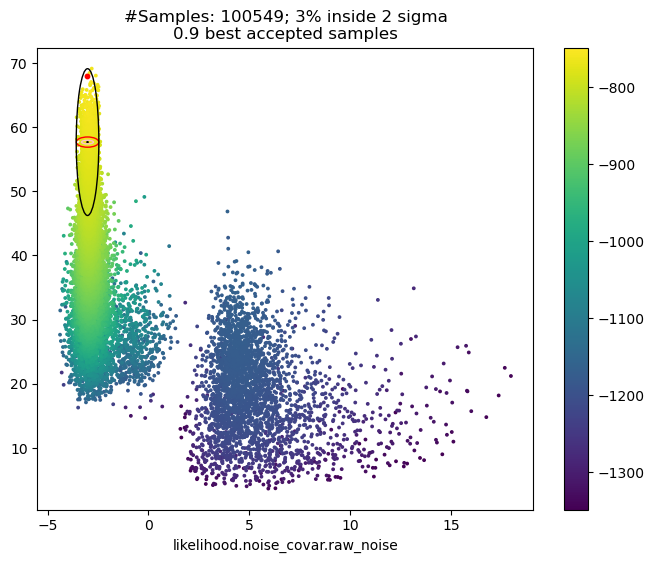

(None, None)

In [ ]:
model_name = "k1"
model_likelihood_MLL = gpytorch.likelihoods.GaussianLikelihood()
model_MLL = ExactGPModel(X, y, model_likelihood_MLL, kernel_name=model_name)
nested_sampling_plot(model_MLL, ALL_METRIC_LOGS[model_name]["NestedSampling"]["logs"], xdim=0, ydim=1, filter_type="none", std_filter=None, show_last_num=0.9, return_figure=False, title_add="", fig=None, ax=None, display_figure=True, plot_mll_opt=False, mll_opt_params=None, plot_lap=True, Lap0_logs=ALL_METRIC_LOGS[model_name]["Lap0"]["logs"], LapAIC_logs=ALL_METRIC_LOGS[model_name]["LapAIC"]["logs"], LapBIC_logs=ALL_METRIC_LOGS[model_name]["LapBIC"]["logs"], lap_colors = ["r", "pink", "black"], Lap_hess=ALL_METRIC_LOGS[model_name]["Lap0"]["logs"]["Hessian pre correction"])

In [ ]:
# Level 1 = kernel_under_test
# Level 2 = Metric
# Level 3 = {"name", "logs", "model_evidence_approx"}
print(ALL_METRIC_LOGS["k1"]["AIC"]["model_evidence_approx"]*(-0.5))
ALL_METRIC_LOGS["k1"]["NestedSampling"]["model_evidence_approx"]

tensor(-1146.1220, grad_fn=<MulBackward0>)


-784.6593484198459

In [ ]:
# Make a table of the different model evidence approximations to show how close they are to Nested Sampling
for kernel_under_test in ALL_METRIC_LOGS:
    print(kernel_under_test)
    model_evidence_NS = ALL_METRIC_LOGS[kernel_under_test]["NestedSampling"]["model_evidence_approx"]
    for metric in ALL_METRIC_LOGS[kernel_under_test]:
        if metric == "NestedSampling":
            continue
        model_evidence_other = ALL_METRIC_LOGS[kernel_under_test][metric]["model_evidence_approx"]
        if metric in ["AIC", "BIC"]:
            model_evidence_other = model_evidence_other * (-0.5)
        if metric == "Lap0":
            model_evidence_LAP = ALL_METRIC_LOGS[kernel_under_test]["Lap0"]["logs"]["laplace without replacement"].detach().numpy().item() if type(ALL_METRIC_LOGS[kernel_under_test]["Lap0"]["logs"]["laplace without replacement"]) == torch.Tensor else ALL_METRIC_LOGS[kernel_under_test]["Lap0"]["logs"]["laplace without replacement"]
            print(f"Lap - NS: {model_evidence_LAP} - {model_evidence_NS}")

        print(f"{metric} - NS: {model_evidence_other} - {model_evidence_NS}")

k1
log MAP - NS: -1180.5828258212402 - -784.6593484198459
log ML - NS: -1143.1219932267618 - -784.6593484198459
Lap - NS: -1176.471169204437 - -784.6593484198459
Lap0 - NS: -1180.9417950986203 - -784.6593484198459
LapAIC - NS: -1183.5828258212389 - -784.6593484198459
LapBIC - NS: -1189.966450883869 - -784.6593484198459
AIC - NS: -1146.1219932267604 - -784.6593484198459
BIC - NS: -1152.5056182893904 - -784.6593484198459
k1 + k2
log MAP - NS: -417.2875806504946 - -244.8898394592286
log ML - NS: -378.54019781631825 - -244.8898394592286
Lap - NS: -410.9617996120915 - -244.8898394592286
Lap0 - NS: -419.3919086598737 - -244.8898394592286
LapAIC - NS: -424.0064616743332 - -244.8898394592286
LapBIC - NS: -436.0548307757474 - -244.8898394592286
AIC - NS: -384.5401978162116 - -244.8898394592286
BIC - NS: -397.3074479414717 - -244.8898394592286
k1 + k2 + k3
log MAP - NS: -204.4856465599413 - -220.29633748136158
log ML - NS: -147.35033868896284 - -220.29633748136158
Lap - NS: -196.11991967023462 -

In [ ]:
torch.nn.functional.softplus(torch.tensor(0.541246))

tensor(1.0000)

/home/andreas/anaconda3/envs/laplace/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


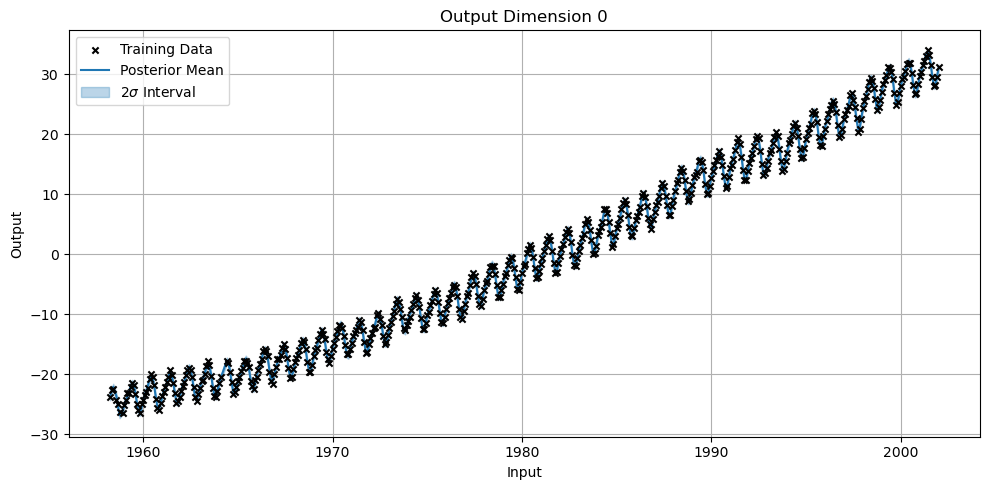

In [ ]:
# Plot the posterior GPs on the datasets

# Setting
kernel_under_test = "k1 + k2 + k3"
train_variant = "log MAP" # "log ML"


likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(X, y, likelihood, kernel_under_test)
model.load_state_dict(ALL_METRIC_LOGS[kernel_under_test][train_variant]["state_dict"])

model.eval()
likelihood.eval()

with torch.no_grad():
    output = likelihood(model(X))
    plot_single_input_gp_posterior(X, y, X, output.mean, output.variance, show=True, return_fig=False, figsize=(10, 5))

In [ ]:
list(model.named_parameters())


[('likelihood.noise_covar.raw_noise',
  Parameter containing:
  tensor([-2.9273], requires_grad=True)),
 ('covar_module.kernels.0.raw_outputscale',
  Parameter containing:
  tensor(-2.0847, requires_grad=True)),
 ('covar_module.kernels.0.base_kernel.raw_lengthscale',
  Parameter containing:
  tensor([[-0.5878]], requires_grad=True)),
 ('covar_module.kernels.1.kernels.0.raw_outputscale',
  Parameter containing:
  tensor(12.6676, requires_grad=True)),
 ('covar_module.kernels.1.kernels.0.base_kernel.raw_lengthscale',
  Parameter containing:
  tensor([[27.6358]], requires_grad=True)),
 ('covar_module.kernels.1.kernels.1.raw_lengthscale',
  Parameter containing:
  tensor([[3.3833]], requires_grad=True)),
 ('covar_module.kernels.1.kernels.1.raw_period_length',
  Parameter containing:
  tensor(0.5412)),
 ('covar_module.kernels.2.raw_outputscale',
  Parameter containing:
  tensor(36.6618, requires_grad=True)),
 ('covar_module.kernels.2.base_kernel.raw_lengthscale',
  Parameter containing:
  te

In [ ]:
# Parameters according to Rasmussen GPML book
# signal variance (SE)
t1 = 66 # 
# lengthscale (SE)
t2 = 67 # (years)
# signal variance (PER*SE)
t3 = 2.4
# lengthscale (SE)
t4 = 90 # (years)
# period length (PER)
t5 = 1.3
# signal variance (RQ)
t6 = 0.66
# length scale (RQ)
t7 = 1.2
# shape parameter? (alpha) (RQ)
t8 = 0.78
# signal variance (SE)
t9 = 0.18
# lengthscale (SE)
t10 = 1.6 # (months)
# noise 
t11 = 0.19